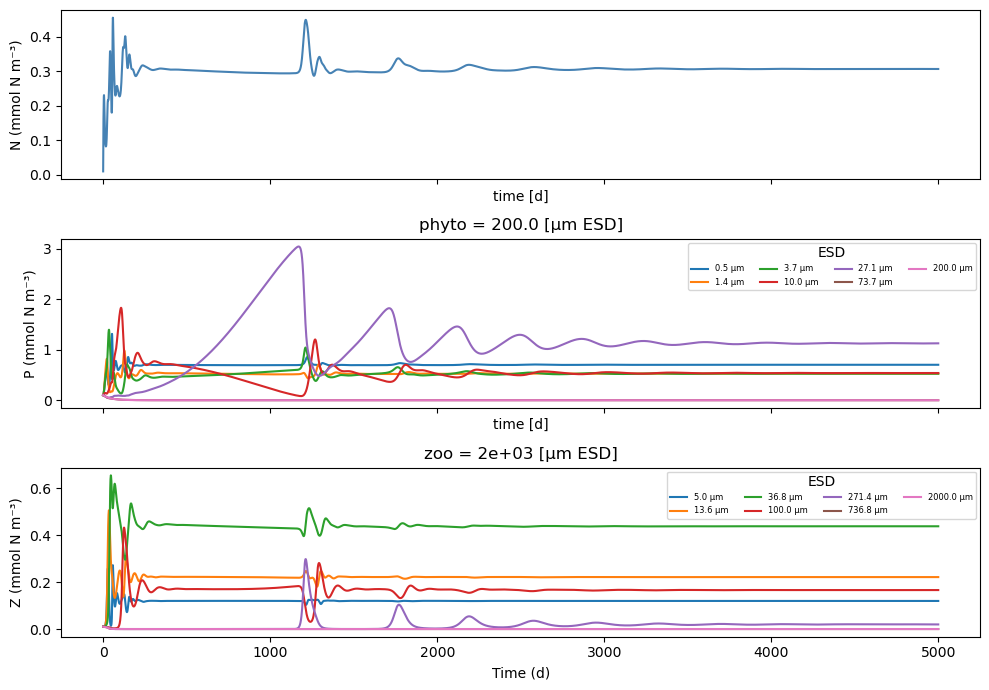

In [3]:
"""
CARIACO Model vs Observations — Comparison Script
==================================================
1. Run IVP to spin up the model
2. Average final window as initial conditions
3. Run stability solver for steady state
4. Aggregate model output to observation categories
5. Plot and print comparison

Designed to be run as a Jupyter notebook (copy cells between # %% markers).
"""


import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xso
import copy

from npxzxf_models import model, input_vars, phyto_esd, zoo_esd
from cariaco_data import (
    load_phyto_obs, load_zoo_obs, load_nutrient_obs,
    aggregate_model_state,
)

# =============================================================================
# CONFIGURABLE PARAMETERS
# =============================================================================
IVP_DAYS       = 5000   # total spin-up integration length (days)
AVG_WINDOW     = 1000   # days to average at end of IVP for initial conditions
TUNING_PARAMS  = {}      # override any input_vars entries here for experiments


# %% =========================================================================
# STAGE 1: IVP SPIN-UP
# =============================================================================
ivp_inputs = copy.deepcopy(input_vars)
if TUNING_PARAMS:
    ivp_inputs.update(TUNING_PARAMS)

ivp_setup = xso.setup(
    solver='solve_ivp',
    model=model,
    time=np.arange(0, IVP_DAYS, 1),
    input_vars=ivp_inputs,
)

with model:
    out_ivp = ivp_setup.xsimlab.run()
out_ivp['time'] = out_ivp.time.round(9)

# Quick spin-up diagnostic
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

axes[0].set_title('IVP Spin-up Diagnostic')
out_ivp['Nutrient__value'].plot(ax=axes[0], color='steelblue')
axes[0].set_ylabel('N (mmol N m⁻³)')

P = out_ivp['Phytoplankton__biomass']
for i, esd in enumerate(phyto_esd):
    P.isel(phyto=i).plot(ax=axes[1], label=f'{esd:.1f} µm')
axes[1].set_ylabel('P (mmol N m⁻³)')
axes[1].legend(fontsize=6, ncol=4, title='ESD')

Z = out_ivp['Zooplankton__biomass']
for i, esd in enumerate(zoo_esd):
    Z.isel(zoo=i).plot(ax=axes[2], label=f'{esd:.1f} µm')
axes[2].set_ylabel('Z (mmol N m⁻³)')
axes[2].legend(fontsize=6, ncol=4, title='ESD')
axes[2].set_xlabel('Time (d)')

plt.tight_layout()
plt.show()


In [4]:
print(out_ivp)

<xarray.Dataset> Size: 7MB
Dimensions:                              (time: 5000, phyto: 7, zoo: 7,
                                          full: 14, clock: 2)
Coordinates:
  * time                                 (time) float64 40kB 0.0 ... 4.999e+03
  * phyto                                (phyto) float64 56B 0.5 1.357 ... 200.0
  * zoo                                  (zoo) float64 56B 5.0 13.57 ... 2e+03
  * clock                                (clock) int64 16B 0 1
Dimensions without coordinates: full
Data variables: (12/60)
    Core__solver_type                    <U9 36B 'solve_ivp'
    FishForcing__forcing_label           <U9 36B 'F_forcing'
    FishForcing__forcing_value           (time) float64 40kB 1.0 1.0 ... 1.0 1.0
    FishForcing__value                   float64 8B 1.0
    FishGrazing__fish_forcing            <U9 36B 'F_forcing'
    FishGrazing__fish_graze_phyto_value  (phyto, time) float64 280kB 0.0 ... 0.0
    ...                                   ...
    ZooMortality

In [13]:
print(out_ivp['Grazing__KsZ'])

<xarray.DataArray 'Grazing__KsZ' ()> Size: 8B
array(3.)
Attributes:
    description:  parameter / half-saturation of Type III grazing response


In [6]:
# %% =========================================================================
# STAGE 2: EXTRACT ICs → RUN STABILITY SOLVER
# =============================================================================
n_avg = out_ivp.Nutrient__value.isel(time=slice(-AVG_WINDOW, None)).mean('time').values
p_avg = out_ivp.Phytoplankton__biomass.isel(time=slice(-AVG_WINDOW, None)).mean('time').values
z_avg = out_ivp.Zooplankton__biomass.isel(time=slice(-AVG_WINDOW, None)).mean('time').values

ss_inputs = copy.deepcopy(input_vars)
if TUNING_PARAMS:
    ss_inputs.update(TUNING_PARAMS)

# Overwrite initial conditions with spin-up averages
ss_inputs['Nutrient']      = {**ss_inputs['Nutrient'],      'value_init': float(n_avg)}
ss_inputs['Phytoplankton'] = {**ss_inputs['Phytoplankton'], 'biomass_init': p_avg}
ss_inputs['Zooplankton']   = {**ss_inputs['Zooplankton'],   'biomass_init': z_avg}

ss_setup = xso.setup(
    solver='stability',
    model=model,
    time=[0, 1],
    input_vars=ss_inputs,
)

with model:
    out_ss = ss_setup.xsimlab.run()

# Extract steady-state values
ss_phyto = out_ss.Phytoplankton__biomass.isel(time=-1).values
ss_zoo   = out_ss.Zooplankton__biomass.isel(time=-1).values
ss_nut   = out_ss.Nutrient__value.isel(time=-1).values

print("\n--- Steady-state size spectra (mmol N m-3) ---")
print(f"  N:  {float(ss_nut):.4f}")
for i, esd in enumerate(phyto_esd):
    print(f"  P[{esd:7.1f} µm]: {ss_phyto[i]:.5f}")
for i, esd in enumerate(zoo_esd):
    print(f"  Z[{esd:7.1f} µm]: {ss_zoo[i]:.5f}")


[INFO] Initial state dimension: 15
[INFO] Initial state: [3.07146938e-01 7.02193282e-01 5.27148093e-01 5.26011525e-01
 5.39060804e-01 1.12711192e+00 1.43560705e-31 3.30424423e-37
 1.19787054e-01 2.21521217e-01 4.38213121e-01 1.66146168e-01
 1.98942742e-02 0.00000000e+00 0.00000000e+00]
[INFO] Steady state found with residual norm: 3.51e-15
  Steady state: [ 3.07119769e-01  7.02166383e-01  5.27133874e-01  5.25942167e-01
  5.38952528e-01  1.12739456e+00 -8.94285386e-42 -1.69601659e-48
  1.19788243e-01  2.21524305e-01  4.38210483e-01  1.66158867e-01
  1.98254967e-02  0.00000000e+00  0.00000000e+00]
[INFO] Computing Jacobian numerically...
[INFO] Successfully computed 15 eigenvalues

--- Steady-state size spectra (mmol N m-3) ---
  N:  0.3071
  P[    0.5 µm]: 0.70217
  P[    1.4 µm]: 0.52713
  P[    3.7 µm]: 0.52594
  P[   10.0 µm]: 0.53895
  P[   27.1 µm]: 1.12739
  P[   73.7 µm]: -0.00000
  P[  200.0 µm]: -0.00000
  Z[    5.0 µm]: 0.11979
  Z[   13.6 µm]: 0.22152
  Z[   36.8 µm]: 0.43821

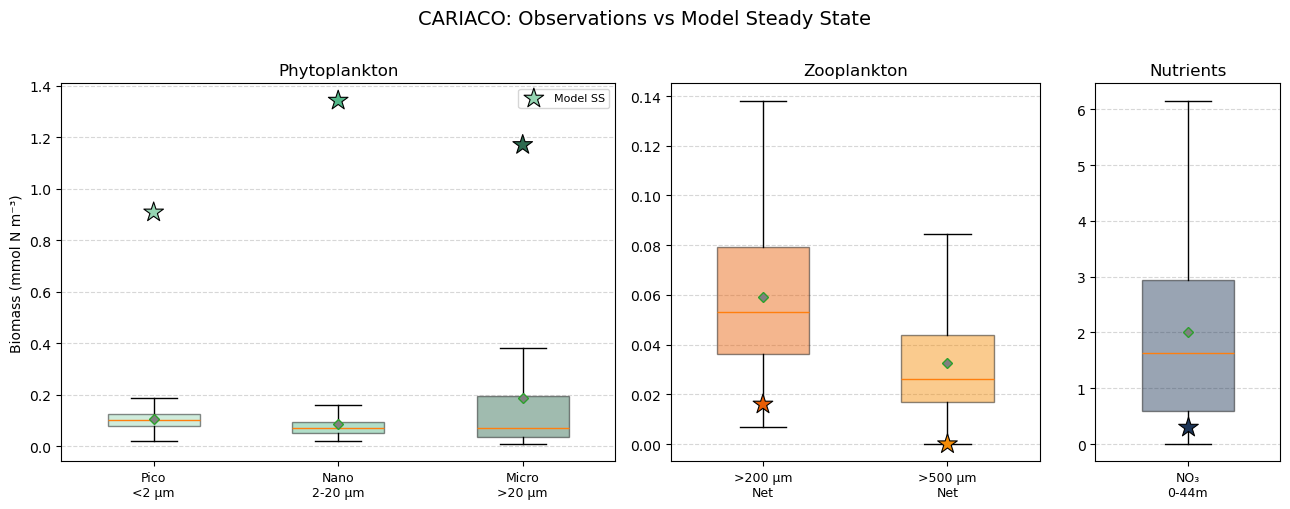


 NUMERICAL SUMMARY: MODEL vs OBSERVATIONS (mmol N m⁻³)
            Component  Obs_Median  Obs_Mean  Model_SS  Diff (Model-Mean)
  Phyto: Pico (<2 µm)     0.10300   0.10500   0.90853            0.80353
Phyto: Nano (2-20 µm)     0.07150   0.08626   1.34266            1.25640
Phyto: Micro (>20 µm)     0.07090   0.18571   1.17040            0.98469
     Zoo: >200 µm Net     0.05304   0.05934   0.01598           -0.04336
     Zoo: >500 µm Net     0.02617   0.03280   0.00000           -0.03280
        Nutrient: NO3     1.63575   2.01581   0.30712           -1.70869


In [7]:
# %% =========================================================================
# STAGE 3: AGGREGATE MODEL → OBSERVATION CATEGORIES
# =============================================================================
model_p, model_z, model_n = aggregate_model_state(
    ss_phyto, ss_zoo, ss_nut, phyto_esd, zoo_esd
)


# %% =========================================================================
# STAGE 4: LOAD OBSERVATIONS
# =============================================================================
phyto_obs = load_phyto_obs()
zoo_obs   = load_zoo_obs()
nut_obs   = load_nutrient_obs()


# %% =========================================================================
# STAGE 5: COMPARISON PLOT
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(13, 5),
                         gridspec_kw={'width_ratios': [3, 2, 1]})

# --- Color scheme ---
green_shades  = ['#95d5b2', '#52b788', '#2d6a4f' ]   # pico, nano, micro
orange_shades = ['#e85d04', '#f48c06']               # >200, >500
blue          = '#1d3557'

star_kw = dict(marker='*', s=220, edgecolor='black', linewidth=0.8, zorder=5)

# --- Phytoplankton ---
ax = axes[0]
bp = ax.boxplot([phyto_obs[c] for c in phyto_obs.columns],
                positions=range(3), widths=0.5, patch_artist=True,
                showmeans=True, showfliers=False,
                meanprops=dict(marker='D', markerfacecolor='gray', markersize=5))
for patch, color in zip(bp['boxes'], green_shades):
    patch.set_facecolor(color)
    patch.set_alpha(0.45)
ax.scatter(range(3), model_p, color=green_shades, **star_kw, label='Model SS')
ax.set_xticks(range(3))
ax.set_xticklabels([ 'Pico\n<2 µm', 'Nano\n2-20 µm', 'Micro\n>20 µm'], fontsize=9)
ax.set_ylabel('Biomass (mmol N m⁻³)')
ax.set_title('Phytoplankton')
ax.legend(fontsize=8)

# --- Zooplankton ---
ax = axes[1]
bp = ax.boxplot([zoo_obs[c] for c in zoo_obs.columns],
                positions=range(2), widths=0.5, patch_artist=True,
                showmeans=True, showfliers=False,
                meanprops=dict(marker='D', markerfacecolor='gray', markersize=5))
for patch, color in zip(bp['boxes'], orange_shades):
    patch.set_facecolor(color)
    patch.set_alpha(0.45)
ax.scatter(range(2), model_z, color=orange_shades, **star_kw)
ax.set_xticks(range(2))
ax.set_xticklabels(['>200 µm\nNet', '>500 µm\nNet'], fontsize=9)
ax.set_title('Zooplankton')

# --- Nutrients ---
ax = axes[2]
bp = ax.boxplot([nut_obs.iloc[:, 0]], positions=[0], widths=0.5,
                patch_artist=True, showmeans=True, showfliers=False,
                meanprops=dict(marker='D', markerfacecolor='gray', markersize=5))
bp['boxes'][0].set_facecolor(blue)
bp['boxes'][0].set_alpha(0.45)
ax.scatter([0], model_n, color=blue, **star_kw)
ax.set_xticks([0])
ax.set_xticklabels([f'NO₃\n0-{int(44.92)}m'], fontsize=9)
ax.set_title('Nutrients')

for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('CARIACO: Observations vs Model Steady State', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


# %% =========================================================================
# STAGE 6: NUMERICAL SUMMARY
# =============================================================================
labels = [
    'Phyto: Pico (<2 µm)',
    'Phyto: Nano (2-20 µm)',
    'Phyto: Micro (>20 µm)',
    'Zoo: >200 µm Net',
    'Zoo: >500 µm Net',
    'Nutrient: NO3',
]

obs_means = [
    phyto_obs['Pico (<2 µm)'].mean(),
    phyto_obs['Nano (2-20 µm)'].mean(),
    phyto_obs['Micro (>20 µm)'].mean(),
    zoo_obs['>200 µm Net'].mean(),
    zoo_obs['>500 µm Net'].mean(),
    nut_obs.iloc[:, 0].mean(),
]

obs_medians = [
    phyto_obs['Pico (<2 µm)'].median(),
    phyto_obs['Nano (2-20 µm)'].median(),
    phyto_obs['Micro (>20 µm)'].median(),
    zoo_obs['>200 µm Net'].median(),
    zoo_obs['>500 µm Net'].median(),
    nut_obs.iloc[:, 0].median(),
]

model_vals = model_p + model_z + model_n

summary = pd.DataFrame({
    'Component': labels,
    'Obs_Median': obs_medians,
    'Obs_Mean': obs_means,
    'Model_SS': model_vals,
})
summary['Diff (Model-Mean)'] = summary['Model_SS'] - summary['Obs_Mean']

print("\n" + "=" * 70)
print(" NUMERICAL SUMMARY: MODEL vs OBSERVATIONS (mmol N m⁻³)")
print("=" * 70)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.5f}"))
print("=" * 70)